In [1]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [2]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Read the csv file using 'read_csv'. Please write your dataset location here.

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Lead Scoring Assignment - Logistic Regression/Leads.csv')
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [6]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.000000,9240.000000,9103.000000,9240.000000,9103.000000,5022.000000,5022.000000
mean,617188.435606,0.385390,3.445238,487.698268,2.362820,14.306252,16.344883
std,23405.995698,0.486714,4.854853,548.021466,2.161418,1.386694,1.811395
min,579533.000000,0.000000,0.000000,0.000000,0.000000,7.000000,11.000000
25%,596484.500000,0.000000,1.000000,12.000000,1.000000,14.000000,15.000000
50%,615479.000000,0.000000,3.000000,248.000000,2.000000,14.000000,16.000000
75%,637387.250000,1.000000,5.000000,936.000000,3.000000,15.000000,18.000000
max,660737.000000,1.000000,251.000000,2272.000000,55.000000,18.000000,20.000000


In [7]:
df.shape

(9240, 37)

In [8]:
df.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


In [9]:
df = df.replace('Select', np.nan)

In [10]:
df.isnull().sum()

,0
Prospect ID,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137


In [11]:
df.drop(['Prospect ID'], axis=1, inplace=True)

In [12]:
df.isnull().sum()

,0
Lead Number,0
Lead Origin,0
Lead Source,36
Do Not Email,0
Do Not Call,0
Converted,0
TotalVisits,137
Total Time Spent on Website,0
Page Views Per Visit,137
Last Activity,103


In [13]:
binaryColumns = ['Do Not Email', 'Do Not Call', 'Search', 'Newspaper',
                 'Digital Advertisement', 'Through Recommendations',
                 'A free copy of Mastering The Interview']

# A simple map function turns them into numbers cleanly
for col in binaryColumns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [14]:
inPercentage = (df.isnull().sum() / len(df)) * 100
for col in inPercentage.index:
    if inPercentage[col] > 40:
        df.drop(col, axis=1, inplace=True)

In [15]:
df.head()

,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,660737,API,Olark Chat,0,0,0,0.0,0,0.0,Page Visited on Website,...,0,0,No,Interested in other courses,No,No,NaN,No,0,Modified
1,660728,API,Organic Search,0,0,0,5.0,674,2.5,Email Opened,...,0,0,No,Ringing,No,No,NaN,No,0,Email Opened
2,660727,Landing Page Submission,Direct Traffic,0,0,1,2.0,1532,2.0,Email Opened,...,0,0,No,Will revert after reading the email,No,No,Mumbai,No,1,Email Opened
3,660719,Landing Page Submission,Direct Traffic,0,0,0,1.0,305,1.0,Unreachable,...,0,0,No,Ringing,No,No,Mumbai,No,0,Modified
4,660681,Landing Page Submission,Google,0,0,1,2.0,1428,1.0,Converted to Lead,...,0,0,No,Will revert after reading the email,No,No,Mumbai,No,0,Modified


In [16]:
# Calculate the 99th percentile value for both columns
percentile99Visits = df['TotalVisits'].quantile(0.99)
percentile99PageViews = df['Page Views Per Visit'].quantile(0.99)

# Cap any values exceeding the 99th percentile
df['TotalVisits'] = np.where(df['TotalVisits'] > percentile99Visits, percentile99Visits, df['TotalVisits'])
df['Page Views Per Visit'] = np.where(df['Page Views Per Visit'] > percentile99PageViews, percentile99PageViews, df['Page Views Per Visit'])

In [17]:
df.head()

,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,...,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,City,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,660737,API,Olark Chat,0,0,0,0.0,0,0.0,Page Visited on Website,...,0,0,No,Interested in other courses,No,No,NaN,No,0,Modified
1,660728,API,Organic Search,0,0,0,5.0,674,2.5,Email Opened,...,0,0,No,Ringing,No,No,NaN,No,0,Email Opened
2,660727,Landing Page Submission,Direct Traffic,0,0,1,2.0,1532,2.0,Email Opened,...,0,0,No,Will revert after reading the email,No,No,Mumbai,No,1,Email Opened
3,660719,Landing Page Submission,Direct Traffic,0,0,0,1.0,305,1.0,Unreachable,...,0,0,No,Ringing,No,No,Mumbai,No,0,Modified
4,660681,Landing Page Submission,Google,0,0,1,2.0,1428,1.0,Converted to Lead,...,0,0,No,Will revert after reading the email,No,No,Mumbai,No,0,Modified


In [18]:
# Extract the list of categorical column names
categoricalColumns = df.select_dtypes(include=['object']).columns

# This creates a complete dataframe with numerical columns intact and categories dummy-encoded
dfEncoded = pd.get_dummies(df, columns=categoricalColumns, drop_first=True, dtype=int)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fill any remaining NaNs in the numeric columns before splitting
dfEncoded['TotalVisits'] = dfEncoded['TotalVisits'].fillna(dfEncoded['TotalVisits'].median())
dfEncoded['Page Views Per Visit'] = dfEncoded['Page Views Per Visit'].fillna(dfEncoded['Page Views Per Visit'].median())

# 1. Isolate the target variable (y) and features (X) from dfEncoded
# We drop 'Converted' (target) and 'Lead Number' (identifier) from X
X = dfEncoded.drop(['Converted', 'Lead Number'], axis=1)
y = dfEncoded['Converted']

# 2. Perform the 70-30 split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=100)

# 3. Apply StandardScaler to the continuous columns
scaler = StandardScaler()
numericFeatures = ['TotalVisits', 'Total Time Spent on Website', 'Page Views Per Visit']

X_train[numericFeatures] = scaler.fit_transform(X_train[numericFeatures])
X_test[numericFeatures] = scaler.transform(X_test[numericFeatures])

In [20]:
# Run a baseline RFE to select top 15 features
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)
rfe = RFE(lr, n_features_to_select=15)
rfe = rfe.fit(X_train, y_train)
rfe

RFE(estimator=LogisticRegression(), n_features_to_select=15)

In [21]:
# Filter columns down to those chosen by RFE
supportedCols = X_train.columns[rfe.support_]
X_trainRFE = X_train[supportedCols]
X_trainRFE

,Lead Source_Welingak Website,Last Activity_SMS Sent,Tags_Closed by Horizzon,Tags_Diploma holder (Not Eligible),Tags_Interested in full time MBA,Tags_Interested in other courses,Tags_Lost to EINS,Tags_Not doing further education,Tags_Ringing,Tags_Will revert after reading the email,Tags_invalid number,Tags_number not provided,Tags_switched off,Tags_wrong number given,Last Notable Activity_Modified
1871,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
6795,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3516,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
8105,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0
3934,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
79,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1
8039,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6936,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [23]:
import statsmodels.api as sm

# Add a constant term to the RFE-selected training features
X_trainSM = sm.add_constant(X_trainRFE)

# Fit the logistic regression model
lrModel = sm.GLM(y_train, X_trainSM, family=sm.families.Binomial()).fit()

# Print the summary to inspect p-values
print(lrModel.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6452
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1483.3
Date:                Wed, 08 Jul 2026   Deviance:                       2966.5
Time:                        10:48:29   Pearson chi2:                 1.67e+04
No. Iterations:                    23   Pseudo R-squ. (CS):             0.5813
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def calculateVif(df):
    vifDf = pd.DataFrame()
    vifDf["Feature"] = df.columns
    vifDf["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    vifDf["VIF"] = round(vifDf["VIF"], 2)
    return vifDf.sort_values(by="VIF", ascending=False)

# Check VIF for the RFE features (exclude the constant column if you pass it)
calculateVif(X_trainRFE)

,Feature,VIF
1,Last Activity_SMS Sent,1.44
14,Last Notable Activity_Modified,1.30
9,Tags_Will revert after reading the email,1.29
5,Tags_Interested in other courses,1.11
8,Tags_Ringing,1.09
2,Tags_Closed by Horizzon,1.06
0,Lead Source_Welingak Website,1.03
12,Tags_switched off,1.03
7,Tags_Not doing further education,1.03
6,Tags_Lost to EINS,1.03


In [27]:
# Re-fit and check again
X_trainSM = sm.add_constant(X_trainRFE)
lrModel = sm.GLM(y_train, X_trainSM, family=sm.families.Binomial()).fit()
print(lrModel.summary())
calculateVif(X_trainRFE)

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6452
Model Family:                Binomial   Df Model:                           15
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1483.3
Date:                Wed, 08 Jul 2026   Deviance:                       2966.5
Time:                        10:50:22   Pearson chi2:                 1.67e+04
No. Iterations:                    23   Pseudo R-squ. (CS):             0.5813
Covariance Type:            nonrobust                                         
                                               coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

,Feature,VIF
1,Last Activity_SMS Sent,1.44
14,Last Notable Activity_Modified,1.30
9,Tags_Will revert after reading the email,1.29
5,Tags_Interested in other courses,1.11
8,Tags_Ringing,1.09
2,Tags_Closed by Horizzon,1.06
0,Lead Source_Welingak Website,1.03
12,Tags_switched off,1.03
7,Tags_Not doing further education,1.03
6,Tags_Lost to EINS,1.03


In [29]:
y_train_pred = lrModel.predict(X_trainSM)
y_train_pred

,0
1871,0.008256
6795,0.184474
3516,0.008256
8105,0.075377
3934,0.037241
...,...
350,0.969209
79,0.843327
8039,0.184474
6936,0.037241


In [30]:
# Create a new DataFrame with actual conversion values
yTrainPredFinal = pd.DataFrame({'Converted': y_train.values, 'Converted_Prob': y_train_pred})

# Assign the Lead ID / Index back so you can map it to original records if needed
yTrainPredFinal['LeadID'] = y_train.index

yTrainPredFinal.head()

,Converted,Converted_Prob,LeadID
1871,0,0.008256,1871
6795,0,0.184474,6795
3516,0,0.008256,3516
8105,0,0.075377,8105
3934,0,0.037241,3934


In [31]:
# Map probabilities > 0.5 to 1, else 0
yTrainPredFinal['Predicted'] = yTrainPredFinal.Converted_Prob.map(lambda x: 1 if x > 0.5 else 0)

yTrainPredFinal.head()

,Converted,Converted_Prob,LeadID,Predicted
1871,0,0.008256,1871,0
6795,0,0.184474,6795,0
3516,0,0.008256,3516,0
8105,0,0.075377,8105,0
3934,0,0.037241,3934,0


In [32]:
from sklearn import metrics

# Confusion matrix
confusion = metrics.confusion_matrix(yTrainPredFinal.Converted, yTrainPredFinal.Predicted)
print("Confusion Matrix:")
print(confusion)

# Overall accuracy
accuracy = metrics.accuracy_score(yTrainPredFinal.Converted, yTrainPredFinal.Predicted)
print(f"\nInitial Accuracy: {round(accuracy * 100, 2)}%")

Confusion Matrix:
[[3845  157]
 [ 337 2129]]

Initial Accuracy: 92.36%


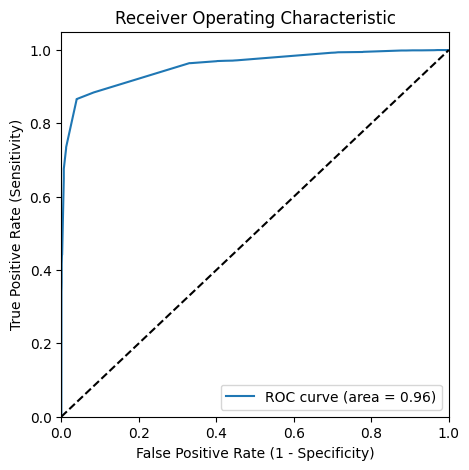

In [33]:
import matplotlib.pyplot as plt

def drawRoc(actual, probs):
    fpr, tpr, thresholds = metrics.roc_curve(actual, probs, drop_intermediate=False)
    aucScore = metrics.roc_auc_score(actual, probs)
    plt.figure(figsize=(5, 5))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {round(aucScore, 2)})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

# Draw the curve
drawRoc(yTrainPredFinal.Converted, yTrainPredFinal.Converted_Prob)

In [34]:
# Create columns for thresholds from 0.0 to 0.9
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    yTrainPredFinal[i] = yTrainPredFinal.Converted_Prob.map(lambda x: 1 if x > i else 0)

yTrainPredFinal.head()

,Converted,Converted_Prob,LeadID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
1871,0,0.008256,1871,0,1,0,0,0,0,0,0,0,0,0
6795,0,0.184474,6795,0,1,1,0,0,0,0,0,0,0,0
3516,0,0.008256,3516,0,1,0,0,0,0,0,0,0,0,0
8105,0,0.075377,8105,0,1,0,0,0,0,0,0,0,0,0
3934,0,0.037241,3934,0,1,0,0,0,0,0,0,0,0,0


In [35]:
cutoffDf = pd.DataFrame(columns=['threshold', 'accuracy', 'sensitivity', 'specificity'])

for i in numbers:
    cm1 = metrics.confusion_matrix(yTrainPredFinal.Converted, yTrainPredFinal[i])
    total1 = sum(sum(cm1))

    # Extract metrics from confusion matrix
    accuracy = (cm1[0,0] + cm1[1,1]) / total1
    specificity = cm1[0,0] / (cm1[0,0] + cm1[0,1])
    sensitivity = cm1[1,1] / (cm1[1,1] + cm1[1,0])

    cutoffDf.loc[i] = [i, accuracy, sensitivity, specificity]

print(cutoffDf)

     threshold  accuracy  sensitivity  specificity
0.0        0.0  0.381262     1.000000     0.000000
0.1        0.1  0.781540     0.964315     0.668916
0.2        0.2  0.904143     0.884428     0.916292
0.3        0.3  0.924552     0.866180     0.960520
0.4        0.4  0.923624     0.863341     0.960770
0.5        0.5  0.923624     0.863341     0.960770
0.6        0.6  0.923624     0.863341     0.960770
0.7        0.7  0.891156     0.734793     0.987506
0.8        0.8  0.891156     0.734793     0.987506
0.9        0.9  0.872449     0.675994     0.993503


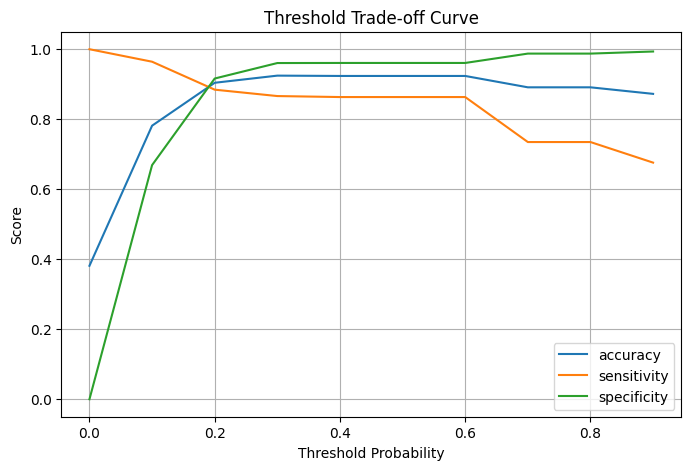

In [36]:
# Plot accuracy, sensitivity, and specificity against thresholds
cutoffDf.plot.line(x='threshold', y=['accuracy', 'sensitivity', 'specificity'], figsize=(8, 5))
plt.title('Threshold Trade-off Curve')
plt.xlabel('Threshold Probability')
plt.ylabel('Score')
plt.grid(True)
plt.show()

In [37]:
# Replace 0.37 with your exact intersection point from the plot
optimalCutoff = 0.37

yTrainPredFinal['Final_Predicted'] = yTrainPredFinal.Converted_Prob.map(lambda x: 1 if x > optimalCutoff else 0)

# Generate the Lead Score (Scale of 0 to 100) requested by the business team
yTrainPredFinal['Lead_Score'] = round(yTrainPredFinal['Converted_Prob'] * 100)

yTrainPredFinal.head()

,Converted,Converted_Prob,LeadID,Predicted,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,Final_Predicted,Lead_Score
1871,0,0.008256,1871,0,1,0,0,0,0,0,0,0,0,0,0,1.0
6795,0,0.184474,6795,0,1,1,0,0,0,0,0,0,0,0,0,18.0
3516,0,0.008256,3516,0,1,0,0,0,0,0,0,0,0,0,0,1.0
8105,0,0.075377,8105,0,1,0,0,0,0,0,0,0,0,0,0,8.0
3934,0,0.037241,3934,0,1,0,0,0,0,0,0,0,0,0,0,4.0


In [38]:
# Filter X_test down to the same features used in the final training model
X_testRFE = X_test[X_trainRFE.columns]

# Add the constant term for statsmodels
X_testSM = sm.add_constant(X_testRFE)

# Predict the conversion probabilities for the test set
y_test_pred = lrModel.predict(X_testSM)

In [39]:
# Create a final evaluation dataframe for the test set
yTestPredFinal = pd.DataFrame({'Converted': y_test.values, 'Converted_Prob': y_test_pred})
yTestPredFinal['LeadID'] = y_test.index

yTestPredFinal.head()

,Converted,Converted_Prob,LeadID
4269,1,0.688967,4269
2376,1,0.996766,2376
7766,1,0.969209,7766
9199,0,0.037241,9199
4359,1,0.969209,4359


In [40]:
# Use the optimal cutoff found from your intersection plot
optimalCutoff = 0.20

yTestPredFinal['Final_Predicted'] = yTestPredFinal.Converted_Prob.map(lambda x: 1 if x > optimalCutoff else 0)
yTestPredFinal['Lead_Score'] = round(yTestPredFinal['Converted_Prob'] * 100)

yTestPredFinal.head()

,Converted,Converted_Prob,LeadID,Final_Predicted,Lead_Score
4269,1,0.688967,4269,1,69.0
2376,1,0.996766,2376,1,100.0
7766,1,0.969209,7766,1,97.0
9199,0,0.037241,9199,0,4.0
4359,1,0.969209,4359,1,97.0


In [41]:
# Generate the confusion matrix
testConfusion = metrics.confusion_matrix(yTestPredFinal.Converted, yTestPredFinal.Final_Predicted)
print("Test Confusion Matrix:")
print(testConfusion)

# Calculate metrics
total = sum(sum(testConfusion))
testAccuracy = metrics.accuracy_score(yTestPredFinal.Converted, yTestPredFinal.Final_Predicted)
testSpecificity = testConfusion[0,0] / (testConfusion[0,0] + testConfusion[0,1])
testSensitivity = testConfusion[1,1] / (testConfusion[1,1] + testConfusion[1,0])

print(f"\nFinal Test Accuracy: {round(testAccuracy * 100, 2)}%")
print(f"Final Test Sensitivity: {round(testSensitivity * 100, 2)}%")
print(f"Final Test Specificity: {round(testSpecificity * 100, 2)}%")

Test Confusion Matrix:
[[1530  147]
 [ 117  978]]

Final Test Accuracy: 90.48%
Final Test Sensitivity: 89.32%
Final Test Specificity: 91.23%
